# 函数调用与 Agent

> 问模型「现在北京几度」，它开始一本正经地编一个数字——答案根本不在参数里，而在气象台的 API 里。实时天气、精确计算、仓库状态：答案位于模型外部时，继续生成文字并不能可靠地得到结果，模型需要学会「发起一次调用」。
>
> 本章介绍函数调用与 Agent 的四组核心内容：
>
> 1. **调用链路**：Function Call 把回答拆成 `模型生成调用 → 外部程序执行 → 结果写回对话 → 模型组织回答`。
> 2. **训练方法**：专门样本、Chat Template 与 Token 级 Loss Mask 教模型生成符合 Schema 的调用参数。
> 3. **Agent 循环**：模型反复执行调用、回填和再决策，并根据当前结果判断是否结束。
> 4. **工程与协议**：Message 结构、Token 计量、失败处理，以及 Function Call、Tool Use 与 MCP 的接口关系共同决定系统如何落地。

问题「357 × 289 等于多少」适合交给计算器，问题「北京现在的天气如何」需要查询实时 API。模型可以理解这两个请求，却不能只依靠参数可靠地完成精确计算或读取不断变化的外部数据。

本章分三步走。第一步讲清 Function Call 的数据流：模型生成函数名和结构化参数，外部程序执行，结果写回对话，模型再组织自然语言答案。第二步讲训练：这种「该调工具时输出 JSON、拿到结果后好好说话」的能力，靠的是什么样的样本、loss 打在哪些 token 上。第三步把镜头拉远：当这条链路被放进循环、由模型自己决定下一步和何时停止，得到的就是 Agent。

`用户请求 → 函数与参数 → 程序执行 → 工具结果 → 最终回答`

下面从两类典型失败开始。

## 1. Function Call 的作用

LLM 的知识来自训练数据，训练数据有一个时间截止点。问模型「今天北京多少度」，它会基于训练时见过的天气统计给出一个笼统的回答，但不可能知道今天的真实天气。这是第一个限制——知识截止。

第二个限制是数值计算。Transformer 的基本运算是矩阵乘法和 softmax，并不擅长精确的多位数乘法。让模型直接算 357 × 289，结果常常是错的。模型给出的答案看起来合理（数量级对、个位数对），但中间几位数字往往出错。

下面用代码模拟这两种失败。

In [1]:
# 模拟 LLM 的两个典型失败：知识截止 + 数值计算错误

# 场景 1：知识截止
# 模型的训练数据是过去的，无法知道"今天"的真实数据
def fake_llm_today_weather():
    # 一个不懂工具的 LLM 被问到今天的天气
    return "北京今天的天气我无法实时查询，但通常这个季节气温在 20-30°C 之间。"

print("=== 失败 1：知识截止 ===")
print("用户：北京今天多少度？")
print(f"模型：{fake_llm_today_weather()}")
print("问题：模型不知道今天的真实天气，只能给一个笼统的猜测")
print()

# 场景 2：数值计算错误
# 模拟一个会算错的"模型"——它输出一个看起来合理但错的答案
def fake_llm_multiply(a, b):
    # 模拟 LLM 算乘法，可能算错
    correct = a * b
    wrong = correct + 1234  # 故意给一个错的答案
    return wrong

a, b = 357, 289
correct = a * b
llm_answer = fake_llm_multiply(a, b)
print("=== 失败 2：数值计算错误 ===")
print(f"用户：{a} × {b} 等于多少？")
print(f"模型：{llm_answer}")
print(f"正确：{correct}")
print(f"差距：模型答案比正确答案多了 {llm_answer - correct}")
print()
print("结论：这两类问题靠模型自己是解决不了的。需要给它一个外部接口。")

=== 失败 1：知识截止 ===
用户：北京今天多少度？
模型：北京今天的天气我无法实时查询，但通常这个季节气温在 20-30°C 之间。
问题：模型不知道今天的真实天气，只能给一个笼统的猜测

=== 失败 2：数值计算错误 ===
用户：357 × 289 等于多少？
模型：104407
正确：103173
差距：模型答案比正确答案多了 1234

结论：这两类问题靠模型自己是解决不了的。需要给它一个外部接口。


## 2. Function Call 的完整流程

Function Call 的核心思路是把"执行"和"决策"分开：

- 决策（该不该调用工具、调用哪个、传什么参数）由模型完成
- 执行（真的去查天气、算数、查数据库）由外部程序完成

完整流程分六步。下面用一个具体例子走一遍：用户问「北京今天多少度？」。

第一步：定义工具。每个工具是一个 JSON 描述，告诉模型这个工具叫什么、做什么、需要什么参数。
第二步：把工具描述注入到 system prompt。模型在生成回复前会看到这段描述。
第三步：模型生成回复。如果它判断需要调用工具，输出的不是自然语言，而是一段结构化 JSON。
第四步：外部程序解析这段 JSON，调用对应函数。
第五步：把执行结果包装成一个新的对话消息，加进对话历史。
第六步：模型基于完整对话历史（含工具结果）生成最终的自然语言回复。

In [2]:
# 第一步：定义可用工具
# 每个工具是一个 dict，包含 name/description/parameters 三部分

import json

tools = [
    {
        "name": "get_weather",
        "description": "查询指定城市的当前天气",
        "parameters": {
            "city": {"type": "string", "description": "城市名"},
            "unit": {"type": "string", "enum": ["celsius", "fahrenheit"], "description": "温度单位"}
        }
    },
    {
        "name": "calculate",
        "description": "执行数学表达式计算",
        "parameters": {
            "expression": {"type": "string", "description": "数学表达式"}
        }
    }
]

print("=== 已定义的工具 ===")
for t in tools:
    print(f"\n工具名：{t['name']}")
    print(f"  说明：{t['description']}")
    print(f"  参数：")
    for pname, pinfo in t['parameters'].items():
        print(f"    {pname} ({pinfo['type']}): {pinfo['description']}")

=== 已定义的工具 ===

工具名：get_weather
  说明：查询指定城市的当前天气
  参数：
    city (string): 城市名
    unit (string): 温度单位

工具名：calculate
  说明：执行数学表达式计算
  参数：
    expression (string): 数学表达式


In [3]:
# 第二步：把工具描述拼进 system prompt
# 这一段是模型可见的，模型据此判断要不要调用工具、调用哪个

def build_system_prompt(tools):
    # 根据工具列表生成系统提示
    lines = ["你是一个助手，可以使用以下工具。当需要外部信息时，请输出 JSON 格式的调用请求。", ""]
    lines.append("可用工具：")
    for t in tools:
        lines.append(f"\n工具：{t['name']}")
        lines.append(f"  说明：{t['description']}")
        lines.append(f"  参数：")
        for pname, pinfo in t['parameters'].items():
            lines.append(f"    - {pname}: {pinfo['description']}")
    return "\n".join(lines)

system_prompt = build_system_prompt(tools)
print("=== System Prompt（模型会看到这段）===")
print(system_prompt)

=== System Prompt（模型会看到这段）===
你是一个助手，可以使用以下工具。当需要外部信息时，请输出 JSON 格式的调用请求。

可用工具：

工具：get_weather
  说明：查询指定城市的当前天气
  参数：
    - city: 城市名
    - unit: 温度单位

工具：calculate
  说明：执行数学表达式计算
  参数：
    - expression: 数学表达式


In [4]:
# 第三步：模拟模型生成 JSON 调用请求
# 实际中这是模型 forward 出来的 token 序列；这里手动模拟一个合理的输出

user_query = "北京今天多少度？"

# 假设模型经过训练后，面对这个用户问题和上面的工具列表，会输出这样的 JSON
model_output = json.dumps({
    "tool_call": {
        "name": "get_weather",
        "arguments": {"city": "北京", "unit": "celsius"}
    }
}, ensure_ascii=False, indent=2)

print("=== 模型输出 ===")
print(f"用户：{user_query}")
print("模型没有输出自然语言，而是输出 JSON：")
print(model_output)
print()
print("关键观察：模型判断需要外部信息，于是选择 get_weather 工具，参数填了 city='北京'。")

=== 模型输出 ===
用户：北京今天多少度？
模型没有输出自然语言，而是输出 JSON：
{
  "tool_call": {
    "name": "get_weather",
    "arguments": {
      "city": "北京",
      "unit": "celsius"
    }
  }
}

关键观察：模型判断需要外部信息，于是选择 get_weather 工具，参数填了 city='北京'。


In [5]:
# 第四步 + 第五步：外部程序执行工具，结果回填进对话历史

# 模拟工具的真实实现
def execute_tool(name, arguments):
    # 根据工具名执行对应的函数
    if name == "get_weather":
        # 实际中这里会调用真实的天气 API
        return {"temperature": 22, "condition": "晴", "humidity": 45}
    elif name == "calculate":
        # 实际中这里会调用真实的计算器
        return {"result": eval(arguments["expression"])}
    return {"error": f"未知工具：{name}"}

# 解析模型输出的 JSON，执行对应工具
parsed = json.loads(model_output)
call = parsed["tool_call"]
tool_result = execute_tool(call["name"], call["arguments"])

print("=== 工具执行 ===")
print(f"调用：{call['name']}({call['arguments']})")
print(f"返回：{tool_result}")
print()

# 构造完整的对话历史，把工具结果作为新的消息加进去
messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_query},
    {"role": "assistant", "content": model_output},
    {"role": "tool", "name": call["name"], "content": json.dumps(tool_result, ensure_ascii=False)},
]

print("=== 完整对话历史（此时已含工具结果）===")
for m in messages:
    role = m["role"]
    content = m["content"]
    if len(content) > 80:
        content = content[:80] + "..."
    print(f"[{role}] {content}")

=== 工具执行 ===
调用：get_weather({'city': '北京', 'unit': 'celsius'})
返回：{'temperature': 22, 'condition': '晴', 'humidity': 45}

=== 完整对话历史（此时已含工具结果）===
[system] 你是一个助手，可以使用以下工具。当需要外部信息时，请输出 JSON 格式的调用请求。

可用工具：

工具：get_weather
  说明：查询指定城市的当前...
[user] 北京今天多少度？
[assistant] {
  "tool_call": {
    "name": "get_weather",
    "arguments": {
      "city": "...
[tool] {"temperature": 22, "condition": "晴", "humidity": 45}


In [6]:
# 第六步：模型基于完整对话历史生成最终自然语言回复

# 模拟模型生成的最终回复
final_reply = "北京今天 22°C，晴天。"

print("=== 最终回复 ===")
print(f"模型：{final_reply}")
print()
print("关键观察：模型看到工具返回的温度=22、天气=晴后，把它们组合成一句自然语言。")
print("用户感知到的是一句普通的回答，工具调用的细节被隐藏了。")

=== 最终回复 ===
模型：北京今天 22°C，晴天。

关键观察：模型看到工具返回的温度=22、天气=晴后，把它们组合成一句自然语言。
用户感知到的是一句普通的回答，工具调用的细节被隐藏了。


## 3. 多工具场景

实际场景里，一个问题经常需要多个工具。比如用户问「北京今天多少度？另外 357 × 289 等于多少？」，模型需要同时调用 get_weather 和 calculate 两个工具。

这里有两种情况，处理方式不同。

并行调用：两个工具之间没有依赖关系，谁先调谁后调都不影响结果。模型可以在一次输出里同时生成多个调用请求，外部程序并行执行后，把所有结果一次性回填。这种方式延迟低。

串行调用：第二个工具的参数依赖第一个工具的结果。模型必须先调第一个工具，看到结果后再决定调不调第二个、传什么参数。比如「查北京今天多少度，然后告诉我该穿什么」——第二个调用（推荐穿着）依赖第一个调用（天气）的结果。这种情况需要分多轮进行。

In [7]:
# 并行调用：一次生成多个工具调用请求

user_query = "北京今天多少度？另外 357 × 289 等于多少？"

# 模型一次性输出多个调用
model_output = json.dumps({
    "tool_calls": [
        {"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}},
        {"name": "calculate", "arguments": {"expression": "357*289"}}
    ]
}, ensure_ascii=False, indent=2)

print("=== 并行调用 ===")
print(f"用户：{user_query}")
print("模型输出：")
print(model_output)
print()

# 外部程序解析并依次执行（实际中可以并行）
parsed = json.loads(model_output)
for call in parsed["tool_calls"]:
    result = execute_tool(call["name"], call["arguments"])
    print(f"执行 {call['name']} → {result}")

print()
print("关键观察：模型一次输出了两个调用，两个调用之间没有依赖。")
print("外部程序可以并行执行，把两个结果同时回填给模型。")

=== 并行调用 ===
用户：北京今天多少度？另外 357 × 289 等于多少？
模型输出：
{
  "tool_calls": [
    {
      "name": "get_weather",
      "arguments": {
        "city": "北京",
        "unit": "celsius"
      }
    },
    {
      "name": "calculate",
      "arguments": {
        "expression": "357*289"
      }
    }
  ]
}

执行 get_weather → {'temperature': 22, 'condition': '晴', 'humidity': 45}
执行 calculate → {'result': 103173}

关键观察：模型一次输出了两个调用，两个调用之间没有依赖。
外部程序可以并行执行，把两个结果同时回填给模型。


In [8]:
# 串行调用：第二个调用依赖第一个的结果

user_query = "北京今天多少度？穿什么合适？"

# 第一轮：模型先调用天气工具
first_call = json.dumps({
    "tool_call": {"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}}
}, ensure_ascii=False)

print("=== 串行调用 ===")
print(f"用户：{user_query}")
print("\n第 1 轮模型输出：")
print(first_call)

weather_result = execute_tool("get_weather", {"city": "北京", "unit": "celsius"})
print(f"\n工具结果：{weather_result}")
print()

# 第二轮：模型看到天气结果后，决定调用穿衣建议工具
wardrobe_tool_result = {"suggestion": "长袖衬衫加薄外套"}
print("第 2 轮模型输出：基于天气 22°C 晴，调用穿衣建议工具")
print(f"工具结果：{wardrobe_tool_result}")
print()
print("关键观察：第二轮调用依赖第一轮的结果——模型必须先知道温度，才能给出穿衣建议。")
print("这种依赖关系让串行调用必须分多轮完成，延迟比并行高。")
print("注意外部程序在两轮之间只做了「执行 + 回填」：下一步调什么由模型看结果后决定。")
print("把这个过程放进一个循环并让模型自己决定何时停，就是本章最后的 Agent。")

=== 串行调用 ===
用户：北京今天多少度？穿什么合适？

第 1 轮模型输出：
{"tool_call": {"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}}}

工具结果：{'temperature': 22, 'condition': '晴', 'humidity': 45}

第 2 轮模型输出：基于天气 22°C 晴，调用穿衣建议工具
工具结果：{'suggestion': '长袖衬衫加薄外套'}

关键观察：第二轮调用依赖第一轮的结果——模型必须先知道温度，才能给出穿衣建议。
这种依赖关系让串行调用必须分多轮完成，延迟比并行高。
注意外部程序在两轮之间只做了「执行 + 回填」：下一步调什么由模型看结果后决定。
把这个过程放进一个循环并让模型自己决定何时停，就是本章最后的 Agent。


## 4. Message 结构与 Chat Template

前两节的流程里，对话一直以 `messages` 列表的形式在各个环节之间传递。这个格式是应用层组织对话的标准表示：模型内部只能根据前文预测下文，并不知道「用户」或「工具」是什么；应用层却需要区分谁说了什么、哪句是全局指令、哪句是工具结果。message 结构把一段对话拆成一条条消息，每条用一个字典记录发言者和内容。下面用一个贯穿本章的例子拆开它的字段，再看消息发给模型时如何渲染、实际占用多少 token。

In [9]:
# 本章的示例对话：后面的 token 计量和训练样本都用它
sample_messages = [
    {"role": "system", "content": "你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(expression) 计算。"},
    {"role": "user", "content": "北京今天多少度？"},
    {"role": "assistant", "content": "",
     "tool_call": {"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}}},
    {"role": "tool", "name": "get_weather", "content": '{"temperature": 22, "condition": "晴"}'},
    {"role": "assistant", "content": "北京今天 22°C，晴天。"},
]

print("=== 一条完整的工具调用对话 ===")
for m in sample_messages:
    body = json.dumps(m["tool_call"], ensure_ascii=False) if m.get("tool_call") else m["content"]
    print(f"[{m['role']:9s}] {body[:56]}")
print()
print("五个轮次：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。")

=== 一条完整的工具调用对话 ===
[system   ] 你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(express
[user     ] 北京今天多少度？
[assistant] {"name": "get_weather", "arguments": {"city": "北京", "uni
[tool     ] {"temperature": 22, "condition": "晴"}
[assistant] 北京今天 22°C，晴天。

五个轮次：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。


### 4.1 Message 结构

一条 message 有两个核心字段。`role` 表示这条话是谁说的，取值是 system、user、assistant、tool 四种之一；`content` 是这条话的文本内容。四种 role 的语义对照上面的 sample_messages 看最清楚：

| role | 含义 | 样本里的内容 | 特点 |
|:---|:---|:---|:---|
| system | 开发者设定的全局指令与人设 | "你是一个助手，可以使用以下工具……" | 整段对话固定不变，优先级最高，工具描述放在这里 |
| user | 用户的输入 | "北京今天多少度？" | 每轮变化 |
| assistant | 模型生成的输出 | 工具调用 JSON，以及"北京今天 22°C，晴天。" | 模型需要生成的内容，可能携带 tool_call |
| tool | 工具执行结果的回填 | {"temperature": 22, "condition": "晴"} | 用 name 字段标明来自哪个工具 |

除两个核心字段外，还有两个只在特定 role 上出现的条件字段。`tool_call` 挂在 assistant 消息上：模型决定调用工具时，content 可以为空，调用意图（工具名加参数）放在 tool_call 里。`name` 挂在 tool 消息上，标明这串结果由哪个工具返回；一次请求里多个工具并行调用时，模型要靠它区分每段结果的归属。

### 4.2 Chat Template

模型并不直接读 messages 这个 JSON。推理时，框架用 chat template（对话模板）把消息列表渲染成一段连续文本，用 special token 标出每条消息的边界和角色。这一步通常由 `tokenizer.apply_chat_template()` 完成，Part 3 解码策略一节展开过。

以 Qwen 风格的模板为例，system 和 user 两条消息渲染后大致长这样：

```text
<|im_start|>system
你是一个助手，可以使用以下工具：get_weather(city)……<|im_end|>
<|im_start|>user
北京今天多少度？<|im_end|>
<|im_start|>assistant
```

`<|im_start|>role` 标记接下来是某个角色的发言，`<|im_end|>` 标记这条消息结束——两者就是 Part 1 讲过的 special token，在词表里有固定 ID。末尾留一个不闭合的 `<|im_start|>assistant`，把发言权交给模型，模型从这里开始生成。不同模型的模板不同：LLaMA 3 用 `<|start_header_id|>`，GPT 系列用 `<|im_sep|>` 之类。用错模板，模型读到的格式就和训练时不一致，回复质量明显下降，这正是 `apply_chat_template()` 存在的意义——它记得每个模型自己的格式。

### 4.3 Token 数量与上下文长度

messages 渲染成文本后，文本会被 tokenizer 切成 token（切分原理在 Part 1 的前两节）。这就涉及三个在 API 文档和模型卡片里经常一起出现、容易混淆的概念。

token 既不按字数也不按词数。文本经过 tokenizer 的 `encode`，按 BPE 词表切成子词片段，每片算 1 个 token。同一段话，不同模型的 tokenizer 切出的 token 数不同——英文约 3.5 字符/token，中文约 1.5 字符/token。一段文本的 token 数等于 `len(tokenizer.encode(文本))`。下面三个概念用的都是同一套计量方式。

| 概念 | 含义 | 在训练样本里 | 推理阶段 |
|:---|:---|:---|:---|
| 输入 token（input / prompt） | 发给模型的全部文本切出的 token | system + user + tool 这些消息 | Prefill：一次性并行算完 |
| 输出 token（output / completion） | 模型生成的回答切出的 token | assistant 的工具调用 JSON 和最终回复 | Decode：逐个串行生成 |
| 上下文长度（context / window） | 模型一次能处理的最大 token 容量 | 一个上限，不是实际占用 | — |

这和后面 5.1 的 loss mask 用的是同一条边界：训练时用 mask 把消息分成输入位置（system/user/tool，不算 loss）和输出位置（assistant，算 loss）；推理计费时问题从"算不算 loss"变成了"算输入 token 还是输出 token"，但边界相同。

三者的核心关系是一句话：上下文长度是输入 token 与输出 token 之和的上限。

```text
上下文长度（容量上限，例如 128K）
    └─ 本次请求实际占用 = 输入 token + 输出 token
       例：输入 6K + 输出 1K = 7K，没有超过 128K
```

下面的 cell 用 tiktoken 实际数一下 sample_messages 这条对话，看输入和输出各占多少。

In [10]:
# 用 tiktoken 实际数一下第 4 节那条对话的 token
# cl100k_base 是 GPT-3.5/4 系列的编码；换一个 tokenizer，具体数字会变
try:
    import tiktoken
    enc = tiktoken.get_encoding("cl100k_base")
    def n_tokens(text):
        return len(enc.encode(text))
except Exception:
    # tiktoken 未安装时退化为按字符粗估（中文约 1.5 字符/token），数字是近似的
    print("tiktoken 未安装，下面用字符数粗估（近似值）；安装 tiktoken 后会显示真实 token 数\n")
    def n_tokens(text):
        return max(1, round(len(text) / 1.5))

# 和 4.1 的 loss mask 用同一条边界：assistant 算输出，其余算输入
input_tokens = 0
output_tokens = 0
print("逐条 message 数 token：")
for msg in sample_messages:
    role = msg["role"]
    # assistant 的调用意图在 tool_call 里，要计入输出
    if role == "assistant" and msg.get("tool_call"):
        text = json.dumps(msg["tool_call"], ensure_ascii=False)
    else:
        text = msg["content"]
    cnt = n_tokens(text)
    if role == "assistant":
        output_tokens += cnt
        tag = "输出"
    else:
        input_tokens += cnt
        tag = "输入"
    print(f"  [{role:9s}] {tag} | {cnt:3d} token | {text[:24]}")

print()
print(f"输入 token（system + user + tool）= {input_tokens}")
print(f"输出 token（assistant）           = {output_tokens}")
print(f"本次占用上下文 = 输入 + 输出      = {input_tokens + output_tokens}")

逐条 message 数 token：
  [system   ] 输入 |  29 token | 你是一个助手，可以使用以下工具：get_weat
  [user     ] 输入 |   7 token | 北京今天多少度？
  [assistant] 输出 |  23 token | {"name": "get_weather", 
  [tool     ] 输入 |  13 token | {"temperature": 22, "con
  [assistant] 输出 |  11 token | 北京今天 22°C，晴天。

输入 token（system + user + tool）= 49
输出 token（assistant）           = 34
本次占用上下文 = 输入 + 输出      = 83


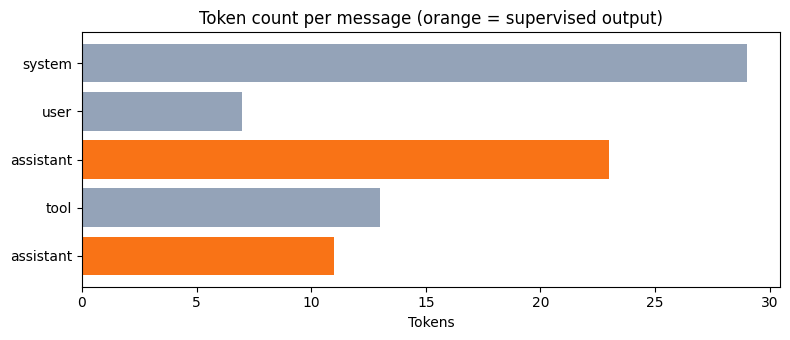

In [11]:
# 重排后本 cell 先于训练节执行，这里自行导入 plt
import matplotlib.pyplot as plt
# === 可视化：输入/输出 token 的构成 ===
# 重新逐条数一遍，按 role 区分输入/输出
counts, labels, colors = [], [], []
for msg in sample_messages:
    role = msg["role"]
    if role == "assistant" and msg.get("tool_call"):
        text = json.dumps(msg["tool_call"], ensure_ascii=False)
    else:
        text = msg["content"]
    counts.append(n_tokens(text))
    labels.append(role)
    colors.append("#f97316" if role == "assistant" else "#94a3b8")

plt.figure(figsize=(8, 3.5))
plt.barh(range(len(counts)), counts, color=colors)
plt.yticks(range(len(counts)), labels)
plt.gca().invert_yaxis()
plt.xlabel("Tokens")
plt.title("Token count per message (orange = supervised output)")
plt.tight_layout()
plt.show()


**输入和输出分开列的三个原因**

第一，计算方式不同导致计费不同。输入走 prefill，并行计算，速度快、成本低；输出走 decode，逐个生成、占显存、速度慢，所以各家 API 的输出 token 单价更高，通常是输入的 3 到 4 倍。

第二，上限不同导致约束不同。很多模型的输出上限远小于上下文长度——例如上下文 128K，但最大输出只有 4K 或 8K。decode 本身慢，加上 KV Cache 随长度线性增长显存占用（Part 4 长上下文一节算过具体数字），都限制了单次能生成的长度。

第三，可优化性不同。多次请求共享同一段 system 时（本节每个请求都带同一份工具描述），prefix caching 能复用这段输入的 KV，命中时输入费用降低约 90%（Part 3 推理系统一节讲过）；输出无法复用，每一步都要重新计算。

API 返回的 usage 字段就是计费依据：`prompt_tokens` 是输入 token，`completion_tokens` 是输出 token。vLLM 部署时的 `max_model_len` 限制的就是输入加输出的总和（Part 5 部署一节）。

## 5. 训练一个支持 Function Call 的模型

到这里，推理侧的机制已经完整：messages 描述对话，chat template 渲染成文本，模型输出工具调用 JSON，外部程序执行回填。但模型不会天生就输出这种格式——一个普通的预训练模型面对「调用 get_weather 工具」的请求，会输出一段看起来像 JSON 但格式不严格、参数也可能编造的文本。

要让模型可靠地走完「理解工具描述 → 输出合法调用 → 基于结果收尾」的整条链路，需要专门的数据构造和训练。训练数据和普通的指令微调数据格式很像，区别在于 assistant 出现两次：一次输出工具调用，一次输出最终回复。先看一个具体样本，再把它走到 token 级的 loss。

In [12]:
# 一个完整的 Function Call 训练样本：对话本体就是第 4 节的 sample_messages
# 区别只在视角：这里把它当作训练数据，关注模型要「学会生成」哪些部分
training_sample = {"messages": sample_messages}

print("=== 一个 Function Call 训练样本 ===")
print(json.dumps(training_sample, ensure_ascii=False, indent=2))
print()
print("这个样本包含完整的对话流：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。")
print("模型通过大量这样的样本，学会在合适的时候输出工具调用 JSON，拿到结果后再组织回答。")

=== 一个 Function Call 训练样本 ===
{
  "messages": [
    {
      "role": "system",
      "content": "你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(expression) 计算。"
    },
    {
      "role": "user",
      "content": "北京今天多少度？"
    },
    {
      "role": "assistant",
      "content": "",
      "tool_call": {
        "name": "get_weather",
        "arguments": {
          "city": "北京",
          "unit": "celsius"
        }
      }
    },
    {
      "role": "tool",
      "name": "get_weather",
      "content": "{\"temperature\": 22, \"condition\": \"晴\"}"
    },
    {
      "role": "assistant",
      "content": "北京今天 22°C，晴天。"
    }
  ]
}

这个样本包含完整的对话流：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。
模型通过大量这样的样本，学会在合适的时候输出工具调用 JSON，拿到结果后再组织回答。


In [13]:
# 一个完整的 Function Call 训练样本

training_sample = {
    "messages": [
        {
            "role": "system",
            "content": "你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(expression) 计算。"
        },
        {
            "role": "user",
            "content": "北京今天多少度？"
        },
        {
            "role": "assistant",
            "content": "",
            "tool_call": {"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}}
        },
        {
            "role": "tool",
            "name": "get_weather",
            "content": '{"temperature": 22, "condition": "晴"}'
        },
        {
            "role": "assistant",
            "content": "北京今天 22°C，晴天。"
        }
    ]
}

print("=== 一个 Function Call 训练样本 ===")
print(json.dumps(training_sample, ensure_ascii=False, indent=2))
print()
print("这个样本包含完整的对话流：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。")
print("模型通过大量这样的样本，学会在合适的时候输出工具调用 JSON。")

=== 一个 Function Call 训练样本 ===
{
  "messages": [
    {
      "role": "system",
      "content": "你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(expression) 计算。"
    },
    {
      "role": "user",
      "content": "北京今天多少度？"
    },
    {
      "role": "assistant",
      "content": "",
      "tool_call": {
        "name": "get_weather",
        "arguments": {
          "city": "北京",
          "unit": "celsius"
        }
      }
    },
    {
      "role": "tool",
      "name": "get_weather",
      "content": "{\"temperature\": 22, \"condition\": \"晴\"}"
    },
    {
      "role": "assistant",
      "content": "北京今天 22°C，晴天。"
    }
  ]
}

这个样本包含完整的对话流：system → user → assistant(工具调用) → tool(结果) → assistant(最终回复)。
模型通过大量这样的样本，学会在合适的时候输出工具调用 JSON。


### 5.1 Template 与 Token 级 Loss

训练与 loss 一节用一轮问答讲过「渲染 → 切分 → 打 mask」的骨架。Function Call 的训练样本多了一个普通对话没有的细节：assistant 出现两次，中间隔着一个 tool 结果轮。所以算 loss 的监督段不是连续的一段，而是两截：工具调用 JSON 一截，最终回复一截。

这一小节把本节开头的训练样本走到 token 级，一共四步，每一步的输出都可以手动复核：

```text
第 1 步   chat template：messages → 一段带 special token 的连续文本
第 2 步   tokenizer：文本 → token 序列，每个 token 都能数出来
第 3 步   labels：监督位置保留 token id，输入位置改成 -100
第 4 步   cross entropy：每个监督位置算 -log p，只对监督位置取平均
```

为什么忽略标记偏偏是 -100？它是 PyTorch `cross_entropy` 默认的 `ignore_index`：被标成 -100 的位置既不进 loss 的分子，也不进分母。cross entropy 本身的手算在训练与 loss 一节已经做过，这里用纯 Python 把带 mask 的完整流程走一遍。真实训练库做的事情完全相同，只是 tokenizer 和模板换成真的。

In [14]:
# 第 1 步：用简化版 chat template 把 messages 渲染成一段连续文本
# 格式取 Qwen 风格：<|im_start|>角色\n 内容 <|im_end|>\n
# 真实 Qwen 模板还会把工具调用 JSON 包在 <tool_call>...</tool_call> 标签里，这里省略
def apply_simple_template(sample):
    """渲染 messages，返回 (文本片段, 是否算 loss) 列表；片段拼起来就是完整训练文本"""
    segments = []
    for msg in sample["messages"]:
        role = msg["role"]
        # 每轮开头的角色标记告诉模型现在轮到谁说话：输入，不算 loss
        segments.append((f"<|im_start|>{role}\n", False))
        if role == "assistant" and msg.get("tool_call"):
            # 工具调用 JSON 是模型要学着输出的内容：算 loss
            body = json.dumps(msg["tool_call"], ensure_ascii=False)
            segments.append((body, True))
        elif role == "assistant":
            # 最终回复同样是模型要学的内容：算 loss
            segments.append((msg["content"], True))
        else:
            # system 指令、user 提问、tool 结果都是输入
            segments.append((msg["content"], False))
        # assistant 说完要自己停：<|im_end|> 也算 loss；其他角色的结束符是输入
        segments.append(("<|im_end|>", role == "assistant"))
        # 结束符后面的换行只是排版：输入
        segments.append(("\n", False))
    return segments

segments = apply_simple_template(training_sample)
full_text = "".join(text for text, _ in segments)

print("=== 第 1 步：chat template 渲染出的完整训练文本 ===")
print(full_text)
print("--- 关键观察 ---")
print("算 loss 的只有两处：assistant 的工具调用 JSON、assistant 的最终回复。")
print("每轮开头的 <|im_start|>assistant 是输入：模型要学的是「接下来输出什么」，")
print("而不是「现在轮到我了」。")
print("但两轮结尾的 <|im_end|> 都算 loss：模型必须学会说完就停，否则生成不会结束。")

=== 第 1 步：chat template 渲染出的完整训练文本 ===
<|im_start|>system
你是一个助手，可以使用以下工具：get_weather(city) 查询天气；calculate(expression) 计算。<|im_end|>
<|im_start|>user
北京今天多少度？<|im_end|>
<|im_start|>assistant
{"name": "get_weather", "arguments": {"city": "北京", "unit": "celsius"}}<|im_end|>
<|im_start|>tool
{"temperature": 22, "condition": "晴"}<|im_end|>
<|im_start|>assistant
北京今天 22°C，晴天。<|im_end|>

--- 关键观察 ---
算 loss 的只有两处：assistant 的工具调用 JSON、assistant 的最终回复。
每轮开头的 <|im_start|>assistant 是输入：模型要学的是「接下来输出什么」，
而不是「现在轮到我了」。
但两轮结尾的 <|im_end|> 都算 loss：模型必须学会说完就停，否则生成不会结束。


In [15]:
# 第 2 步：用一个透明的简化 tokenizer 把文本切成 token 序列
# 切法只有三条规则，保证每个 token 都能用手数出来：
#   1. <|im_start|>、<|im_end|> 整体算 1 个 token，不拆开
#   2. 连续的英文字母/数字/下划线连成 1 个 token，如 get_weather、22、celsius
#   3. 其余每个字符（汉字、标点、空格、换行）各算 1 个 token
SPECIALS = ["<|im_start|>", "<|im_end|>"]

def simple_tokenize(text):
    """按上面三条规则把文本切成 token 列表"""
    tokens = []
    i = 0
    while i < len(text):
        # 规则 1：special token 整体一个
        hit = next((s for s in SPECIALS if text.startswith(s, i)), None)
        if hit is not None:
            tokens.append(hit)
            i += len(hit)
        # 规则 2：英文单词、数字连成一个
        elif text[i].isascii() and (text[i].isalnum() or text[i] == "_"):
            j = i
            while j < len(text) and text[j].isascii() and (text[j].isalnum() or text[j] == "_"):
                j += 1
            tokens.append(text[i:j])
            i = j
        # 规则 3：其余字符一个一个切
        else:
            tokens.append(text[i])
            i += 1
    return tokens

# 切分的同时把 mask 标记带过来：片段算 loss，它切出的 token 就都算
token_list, loss_mask = [], []
for seg_text, seg_loss in segments:
    seg_tokens = simple_tokenize(seg_text)
    token_list.extend(seg_tokens)
    loss_mask.extend([seg_loss] * len(seg_tokens))

# 建一个小词表：special token 固定在前，其余 token 按首次出现顺序编号
vocab = {s: k for k, s in enumerate(SPECIALS)}
for t in token_list:
    if t not in vocab:
        vocab[t] = len(vocab)
input_ids = [vocab[t] for t in token_list]

print("=== 第 2 步：tokenize ===")
print(f"整段训练文本共切出 {len(token_list)} 个 token，词表大小 {len(vocab)}")
print("（真实模型词表约 15 万，BPE 切法更细；这里只覆盖本样本，但流程相同）")
print()
print("抽几段看切法：")
print("  角色头:", simple_tokenize("<|im_start|>assistant\n"))
print("  用户消息:", simple_tokenize("北京今天多少度？"))
print("  最终回复:", simple_tokenize("北京今天 22°C，晴天。"))
print()
print("注意：空格和换行也是 token；JSON 的引号、花括号也各占一个 token。")
print("这就是工具调用的输出 token 比看上去多的原因（5.3 节会实际数一遍）。")

=== 第 2 步：tokenize ===
整段训练文本共切出 135 个 token，词表大小 59
（真实模型词表约 15 万，BPE 切法更细；这里只覆盖本样本，但流程相同）

抽几段看切法：
  角色头: ['<|im_start|>', 'assistant', '\n']
  用户消息: ['北', '京', '今', '天', '多', '少', '度', '？']
  最终回复: ['北', '京', '今', '天', ' ', '22', '°', 'C', '，', '晴', '天', '。']

注意：空格和换行也是 token；JSON 的引号、花括号也各占一个 token。
这就是工具调用的输出 token 比看上去多的原因（5.3 节会实际数一遍）。


In [16]:
# 第 3 步：构造 labels——监督位置保留 token id，输入位置改成 -100
labels = [tid if m else -100 for tid, m in zip(input_ids, loss_mask)]

# 先找出连续的监督区，打印逐 token 对照表时在边界处做标记
runs = []
start = None
for i, m in enumerate(loss_mask + [False]):
    if m and start is None:
        start = i
    elif not m and start is not None:
        runs.append((start, i - 1))
        start = None
run_names = ["工具调用 JSON", "最终回复"]

print("=== 第 3 步：labels 逐 token 对照表（label = -100 表示忽略） ===")
run_no = -1
for i, (tok, lab) in enumerate(zip(token_list, labels)):
    # 进入监督区时插一行说明
    if run_no + 1 < len(runs) and i == runs[run_no + 1][0]:
        run_no += 1
        print(f"------ 监督段 {run_no + 1} 开始（{run_names[run_no]}） ------")
    print(f"{i:3d} | {repr(tok):>14} | {lab:4d}")
    # 离开监督区时插一行小结
    if run_no >= 0 and i == runs[run_no][1]:
        print(f"------ 监督段 {run_no + 1} 结束，共 {i - runs[run_no][0] + 1} 个 token ------")

n_valid = sum(1 for l in labels if l != -100)
print()
print(f"总共 {len(labels)} 个位置：{n_valid} 个算 loss，{len(labels) - n_valid} 个是 -100。")
print("两段监督区不连续，中间隔着整个 tool 结果轮——这正是 Function Call 样本")
print("和普通单轮 SFT 样本最大的区别。")

=== 第 3 步：labels 逐 token 对照表（label = -100 表示忽略） ===
  0 | '<|im_start|>' | -100
  1 |       'system' | -100
  2 |           '\n' | -100
  3 |            '你' | -100
  4 |            '是' | -100
  5 |            '一' | -100
  6 |            '个' | -100
  7 |            '助' | -100
  8 |            '手' | -100
  9 |            '，' | -100
 10 |            '可' | -100
 11 |            '以' | -100
 12 |            '使' | -100
 13 |            '用' | -100
 14 |            '以' | -100
 15 |            '下' | -100
 16 |            '工' | -100
 17 |            '具' | -100
 18 |            '：' | -100
 19 |  'get_weather' | -100
 20 |            '(' | -100
 21 |         'city' | -100
 22 |            ')' | -100
 23 |            ' ' | -100
 24 |            '查' | -100
 25 |            '询' | -100
 26 |            '天' | -100
 27 |            '气' | -100
 28 |            '；' | -100
 29 |    'calculate' | -100
 30 |            '(' | -100
 31 |   'expression' | -100
 32 |            ')' | -100
 33 |            ' ' | -

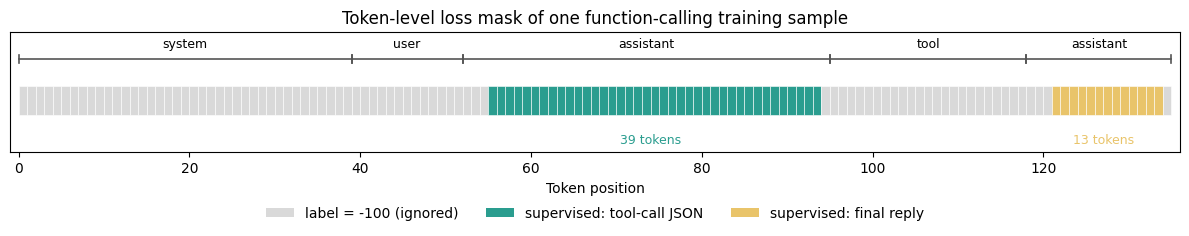

In [17]:
# 可视化：把整个 token 序列画成一条时间轴，一眼看出两段监督区的位置
# 图里的文字按项目规范用英文
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

run_colors = ["#2a9d8f", "#e9c46a"]  # 两段监督区各一种颜色
fig, ax = plt.subplots(figsize=(12, 2.8))
for i in range(len(token_list)):
    color = "#d9d9d9"  # 默认灰色 = label 是 -100
    for r, (a, b) in enumerate(runs):
        if a <= i <= b:
            color = run_colors[r]
    ax.barh(0, 1, left=i, height=1, color=color, edgecolor="white", linewidth=0.4)

# 顶部用短横线标出每条消息覆盖的 token 范围（每条消息从一个 <|im_start|> 开始）
msg_starts = [i for i, t in enumerate(token_list) if t == "<|im_start|>"] + [len(token_list)]
for k in range(len(msg_starts) - 1):
    a, b = msg_starts[k], msg_starts[k + 1] - 1
    role = token_list[a + 1]
    ax.plot([a, b + 1], [1.45, 1.45], color="#555555", linewidth=1.2)
    ax.plot([a, a], [1.3, 1.6], color="#555555", linewidth=1.2)
    ax.plot([b + 1, b + 1], [1.3, 1.6], color="#555555", linewidth=1.2)
    ax.text((a + b + 1) / 2, 1.75, role, ha="center", va="bottom", fontsize=9)

# 在监督区下方标注各自的 token 数
for r, (a, b) in enumerate(runs):
    ax.text((a + b) / 2, -1.15, f"{b - a + 1} tokens", ha="center", va="top",
            fontsize=9, color=run_colors[r])

ax.set_xlim(-1, len(token_list) + 1)
ax.set_ylim(-1.8, 2.4)
ax.set_yticks([])
ax.set_xlabel("Token position")
ax.set_title("Token-level loss mask of one function-calling training sample")
legend_items = [Patch(facecolor="#d9d9d9", label="label = -100 (ignored)"),
                Patch(facecolor=run_colors[0], label="supervised: tool-call JSON"),
                Patch(facecolor=run_colors[1], label="supervised: final reply")]
ax.legend(handles=legend_items, loc="upper center", ncol=3,
          bbox_to_anchor=(0.5, -0.35), frameon=False)
plt.tight_layout()
plt.show()

第 4 步之前，先弄清两个机制。

**shift：位置 i 的预测对象是第 i+1 个 token。** labels 和 input_ids 一样长、逐位对齐，错开一格的约定由模型在内部完成（训练与 loss 一节对比过数据外 shift 和模型内 shift 两种等价做法）。因此 mask 打在 label 上，被监督的是「目标 token」。看一个具体的例子：监督段 1 的第一个 token 是 `{`（位置 55），预测它的上下文恰好到 `<|im_start|>assistant` 和换行为止——这正是推理时模型开始生成的位置。

**-100：跳过，而且不进分母。** 每个监督位置的 loss 是 $-\log p(\text{target} \mid \text{prefix})$——给定前文时，模型分给目标 token 的概率取负对数；总 loss 是监督位置的 loss 之和除以监督位置数。分母不是序列长度：这条样本 135 个位置里只有 52 个监督位置，如果按 135 平均，loss 会被大量输入位置稀释，「在什么位置输出什么」的训练信号就变弱了。

在 PyTorch 里这两件事合成一行：`F.cross_entropy(shift_logits, shift_labels, ignore_index=-100)`。

=== 手算第一个监督位置 ===
位置 54 的 logits 预测位置 55 的 token '{'
logits 前 5 个（共 59 个）: [0.89, 1.82, -0.79, -0.48, 1.1]
softmax 后正确 token 的概率 p = 0.0035
该位置 loss = -log(p) = 5.6666
和 per_token_loss[54] 一致: 5.6666

预测位置共 134 个，其中监督位置 52 个，其余全是 -100
正确平均（分母 = 监督位置数 52）: 4.3990
错误平均（分母 = 全部预测位置 134）: 1.7071

关键观察 1：随机 logits 的平均 loss 约 4.4，接近 log(词表大小) = 4.08——未训练的模型对所有 token 都在瞎猜。
关键观察 2：分母用错了 loss 会凭空变小。训练库都按监督位置数平均。



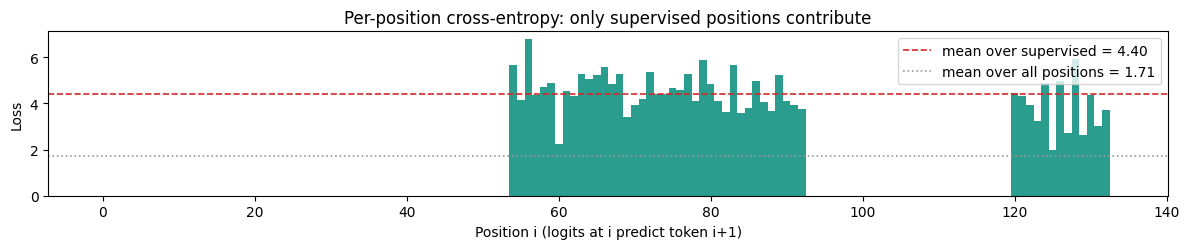

In [18]:
# 第 4 步：逐位置算 cross entropy，只对监督位置取平均
# 真实训练里 logits 来自模型 forward；这里用固定种子的随机数模拟一排 logits，
# 数值本身没有意义，重点是看 -100 的位置如何被跳过
import math
import random

random.seed(42)

def softmax(xs):
    """把一排 logits 变成概率分布（先减最大值，防止 exp 溢出）"""
    m = max(xs)
    exps = [math.exp(x - m) for x in xs]
    return [e / sum(exps) for e in exps]

# 先给每个预测位置造一排 logits：位置 i 的 logits 负责预测 labels[i + 1]
n_predict = len(labels) - 1
all_logits = [[random.gauss(0, 1) for _ in range(len(vocab))] for _ in range(n_predict)]

per_token_loss = []
for i in range(n_predict):
    target = labels[i + 1]
    if target == -100:
        per_token_loss.append(None)  # None 表示被 mask 跳过
        continue
    p_correct = softmax(all_logits[i])[target]
    per_token_loss.append(-math.log(p_correct))

# 手算第一个监督位置，看清楚单个位置的 loss 怎么来的
first_pos = next(i for i, l in enumerate(per_token_loss) if l is not None)
target = labels[first_pos + 1]
probs = softmax(all_logits[first_pos])
print("=== 手算第一个监督位置 ===")
print(f"位置 {first_pos} 的 logits 预测位置 {first_pos + 1} 的 token {repr(token_list[first_pos + 1])}")
print(f"logits 前 5 个（共 {len(vocab)} 个）: {[round(x, 2) for x in all_logits[first_pos][:5]]}")
print(f"softmax 后正确 token 的概率 p = {probs[target]:.4f}")
print(f"该位置 loss = -log(p) = {-math.log(probs[target]):.4f}")
print(f"和 per_token_loss[{first_pos}] 一致: {per_token_loss[first_pos]:.4f}")
print()

valid_losses = [l for l in per_token_loss if l is not None]
print(f"预测位置共 {n_predict} 个，其中监督位置 {len(valid_losses)} 个，其余全是 -100")
mean_loss = sum(valid_losses) / len(valid_losses)
print(f"正确平均（分母 = 监督位置数 {len(valid_losses)}）: {mean_loss:.4f}")
wrong_mean = sum(valid_losses) / n_predict
print(f"错误平均（分母 = 全部预测位置 {n_predict}）: {wrong_mean:.4f}")
print()
print(f"关键观察 1：随机 logits 的平均 loss 约 {mean_loss:.1f}，接近 log(词表大小) = "
      f"{math.log(len(vocab)):.2f}——未训练的模型对所有 token 都在瞎猜。")
print("关键观察 2：分母用错了 loss 会凭空变小。训练库都按监督位置数平均。")
print()

# 逐位置 loss 可视化：灰色 = 被 mask 跳过，绿色 = 监督位置
plt.figure(figsize=(12, 2.6))
heights = [l if l is not None else 0 for l in per_token_loss]
bar_colors = ["#2a9d8f" if l is not None else "#e0e0e0" for l in per_token_loss]
plt.bar(range(n_predict), heights, color=bar_colors, width=1.0)
plt.axhline(mean_loss, color="#d62828", linestyle="--", linewidth=1.2,
            label=f"mean over supervised = {mean_loss:.2f}")
plt.axhline(wrong_mean, color="#999999", linestyle=":", linewidth=1.2,
            label=f"mean over all positions = {wrong_mean:.2f}")
plt.xlabel("Position i (logits at i predict token i+1)")
plt.ylabel("Loss")
plt.title("Per-position cross-entropy: only supervised positions contribute")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5.2 Function Call 训练数据

构造训练样本是 Function Call 训练里最耗工时的部分。常见的三种数据来源：

| 来源 | 做法 | 优缺点 |
|:---|:---|:---|
| 人工标注 | 给标注员看工具列表，让他们编写"用户问题 + 期望的工具调用"对 | 质量高，但成本高、规模难放大 |
| 强模型蒸馏 | 让 GPT-4 这类已经支持工具调用的模型生成调用样本，再用作训练数据 | 规模容易放大，但受限于强模型的能力上限 |
| 真实日志 | 从已有产品的工具调用日志里筛选正确的样本 | 最贴近真实分布，但冷启动阶段没有日志 |

实际项目通常三种混用：先用人工标注做几千条高质量种子数据，再用强模型蒸馏扩到几万条，最后接入真实日志持续优化。

## 6. 错误处理与失败模式

工具调用不是一调用就成功。实际部署中会遇到各种失败，模型和外部程序都需要有能力处理。

下面列出四种最常见的失败模式，每种配一个具体例子。

In [19]:
# 失败模式 1：工具执行失败
# 比如天气 API 超时，或者用户传了一个不存在的城市

def execute_tool_with_failure(name, arguments):
    # 一个可能失败的工具执行器
    if name == "get_weather":
        city = arguments.get("city", "")
        # 模拟"城市不存在"
        if city not in ["北京", "上海", "广州"]:
            return {"error": f"未找到城市：{city}"}
        return {"temperature": 22, "condition": "晴"}
    return {"error": "未知工具"}

# 案例：模型调了一个不存在的城市
result = execute_tool_with_failure("get_weather", {"city": "亚特兰蒂斯"})
print("=== 失败模式 1：工具执行失败 ===")
print("模型调用：get_weather(city='亚特兰蒂斯')")
print(f"工具返回：{result}")
print()
print("工程对策：把错误结果原样回填给模型，让模型生成道歉或追问的回复。")
print("示例：'抱歉，未找到亚特兰蒂斯的天气信息。请问您指的是哪个城市？'")

=== 失败模式 1：工具执行失败 ===
模型调用：get_weather(city='亚特兰蒂斯')
工具返回：{'error': '未找到城市：亚特兰蒂斯'}

工程对策：把错误结果原样回填给模型，让模型生成道歉或追问的回复。
示例：'抱歉，未找到亚特兰蒂斯的天气信息。请问您指的是哪个城市？'


In [20]:
# 失败模式 2：模型选错工具
# 用户问的是计算，但模型调了天气工具

wrong_call = {"name": "get_weather", "arguments": {"city": "357*289"}}
print("=== 失败模式 2：模型选错工具 ===")
print("用户：357 × 289 等于多少？")
print(f"模型调用：{wrong_call}")
print("问题：模型把数学表达式当成了城市名")
print()
print("工程对策：在训练数据里加入更多'用户问题类型 → 正确工具'的样本。")
print("也可以在 system prompt 里强调每个工具的适用场景。")

=== 失败模式 2：模型选错工具 ===
用户：357 × 289 等于多少？
模型调用：{'name': 'get_weather', 'arguments': {'city': '357*289'}}
问题：模型把数学表达式当成了城市名

工程对策：在训练数据里加入更多'用户问题类型 → 正确工具'的样本。
也可以在 system prompt 里强调每个工具的适用场景。


In [21]:
# 失败模式 3：参数不合法
# 比如工具要求 unit 只能是 celsius 或 fahrenheit，模型传了 kelvin

bad_call = {"name": "get_weather", "arguments": {"city": "北京", "unit": "kelvin"}}
print("=== 失败模式 3：参数不合法 ===")
print(f"模型调用：{bad_call}")
print("问题：unit='kelvin' 不在 enum ['celsius', 'fahrenheit'] 内")
print()

# 工程对策：用 JSON Schema 严格校验
valid_units = ["celsius", "fahrenheit"]
actual_unit = bad_call["arguments"]["unit"]
if actual_unit not in valid_units:
    print(f"校验失败：unit 必须是 {valid_units}，但收到了 '{actual_unit}'")
    print("工程对策：在外部程序里加 schema 校验，不合法的参数直接拒绝，")
    print("并把校验错误信息回填给模型，让它重试。")

=== 失败模式 3：参数不合法 ===
模型调用：{'name': 'get_weather', 'arguments': {'city': '北京', 'unit': 'kelvin'}}
问题：unit='kelvin' 不在 enum ['celsius', 'fahrenheit'] 内

校验失败：unit 必须是 ['celsius', 'fahrenheit']，但收到了 'kelvin'
工程对策：在外部程序里加 schema 校验，不合法的参数直接拒绝，
并把校验错误信息回填给模型，让它重试。


In [22]:
# 失败模式 4：工具调用死循环
# 模型反复调用同一个工具，永远不输出最终回复

print("=== 失败模式 4：工具调用死循环 ===")
print("场景：模型连续多次调用 get_weather，每次参数都一样，从不输出最终回复")
print()

# 工程对策：设置最大调用次数
MAX_TOOL_CALLS = 3
call_count = 0
for i in range(MAX_TOOL_CALLS + 2):  # 模拟模型反复调用
    call_count += 1
    if call_count > MAX_TOOL_CALLS:
        print(f"第 {call_count} 次调用：超出最大次数 {MAX_TOOL_CALLS}，强制停止")
        break
    print(f"第 {call_count} 次调用：get_weather(city='北京')")

print()
print("工程对策：在调用循环外面包一层计数器，超过阈值就强制终止，返回兜底回复。")
print("另外可以在训练数据里加入'调一次就回复'的正样本，减少模型重复调用的倾向。")

=== 失败模式 4：工具调用死循环 ===
场景：模型连续多次调用 get_weather，每次参数都一样，从不输出最终回复

第 1 次调用：get_weather(city='北京')
第 2 次调用：get_weather(city='北京')
第 3 次调用：get_weather(city='北京')
第 4 次调用：超出最大次数 3，强制停止

工程对策：在调用循环外面包一层计数器，超过阈值就强制终止，返回兜底回复。
另外可以在训练数据里加入'调一次就回复'的正样本，减少模型重复调用的倾向。


## 7. 标准化工具调用

Function Call 这个名字最早是 OpenAI 在 2023 年 6 月引入的，那时的 API 参数还叫 `functions`。半年后 OpenAI 把它重命名为 Tools，参数变成 `tools`，原本的 `function_call` 字段也改成了 `tool_calls`。这次改名背后是一个更通用的设计：工具不一定是函数，也可以是检索器、代码解释器、文件系统等任何能「被调用」的东西。所以现在社区里更常见的说法是 Tool Use 或 Tool Calling，Function Call 逐渐成了历史叫法。

但各家厂商的 Tool Use 接口仍然各搞各的——OpenAI 一套格式、Anthropic 一套、Google 一套。一个工具要同时支持多个平台，开发者得反复适配。Anthropic 在 2024 年底发布了 MCP（Model Context Protocol），试图统一这个生态。MCP 的核心想法是：把工具的描述和调用协议标准化，让任何兼容 MCP 的工具都能被任何支持 MCP 的模型直接调用，不再需要为每个模型单独适配。

标准化解决的是「工具从哪来、长什么样」。还剩最后一个问题：工具多了、任务长了，谁来编排调用顺序和结束时机？下一节的答案是——交给模型自己。

## 8. 走向 Agent：把工具调用放进循环

先给定义：**Agent** 是让模型自主完成多步任务的循环——模型决定调用什么工具，外部程序执行，结果回填，模型基于结果决定下一步，直到它认为任务完成、输出最终回复。通俗地说，前面几节做的都是「帮模型调好一次工具」，Agent 做的是「把方向盘交给模型」。

回头看，零件其实都已经见过：

- 工具调用（第 2 节）：模型输出结构化 JSON，外部程序解析执行
- 串行调用（第 3 节）：下一步依赖上一步的结果，分多轮进行
- 训练样本（第 5 节）：tool 消息进对话历史，模型看到结果后再决策
- 失败兜底（第 6 节）：错误回填给模型重试，循环外加最大轮数

把这几件事装进一个 `while` 循环，加一个停止条件，就是 agent loop：

```text
while 未超过最大轮数:
    回复 = 模型(完整对话历史)
    if 回复携带 tool_call:
        执行工具，结果作为 tool 消息追加进历史   # 继续循环
    else:
        输出最终回复，停止                       # 模型自己决定结束
```

注意「谁决定停止」：普通工具调用里，调用几轮由外部代码写死；Agent 里停止信号来自模型——它生成自然语言而不是 tool_call，循环自然结束。这正是第 5 节训练样本里两段监督区（会调工具、也会收尾）共同支撑的能力。

In [23]:
# 最小 agent loop：模型 + 工具 + 循环 + 停止条件
# 模型用规则模拟；真实场景里，fake_agent_model 换成一次 LLM API 调用即可

def fake_agent_model(messages):
    """模拟支持工具调用的模型：还没见过工具结果就发起调用，见过就收尾"""
    tool_msgs = [m for m in messages if m["role"] == "tool"]
    if not tool_msgs:
        # 没有任何工具结果：发起第一次调用
        return {"role": "assistant", "content": "",
                "tool_call": {"name": "get_weather",
                              "arguments": {"city": "北京", "unit": "celsius"}}}
    # 已有工具结果：输出最终回复（不携带 tool_call，循环就此停止）
    weather = json.loads(tool_msgs[-1]["content"])
    return {"role": "assistant",
            "content": f"北京今天 {weather['temperature']}°C，{weather['condition']}，建议穿长袖衬衫加薄外套。"}

agent_messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "北京今天多少度？穿什么合适？"},
]

MAX_TURNS = 5  # 兜底：即使模型一直不停，循环也会被强制终止（对应第 6 节的死循环问题）
for turn in range(1, MAX_TURNS + 1):
    reply = fake_agent_model(agent_messages)  # 真实场景：一次模型推理
    agent_messages.append(reply)
    if reply.get("tool_call"):
        call = reply["tool_call"]
        print(f"第 {turn} 轮：模型调用 {call['name']}({call['arguments']})")
        result = execute_tool(call["name"], call["arguments"])
        agent_messages.append({"role": "tool", "name": call["name"],
                               "content": json.dumps(result, ensure_ascii=False)})
        print(f"        工具返回 {result}，追加进历史，进入下一轮")
    else:
        print(f"第 {turn} 轮：模型输出自然语言（无 tool_call），循环停止")
        print(f"\n最终回复：{reply['content']}")
        break

print()
print("关键观察：外部代码只负责循环和兜底，「调什么、何时停」完全由模型的输出决定。")
print("第 3 节的串行调用，其实就是这个循环跑两轮的样子。")

第 1 轮：模型调用 get_weather({'city': '北京', 'unit': 'celsius'})
        工具返回 {'temperature': 22, 'condition': '晴', 'humidity': 45}，追加进历史，进入下一轮
第 2 轮：模型输出自然语言（无 tool_call），循环停止

最终回复：北京今天 22°C，晴，建议穿长袖衬衫加薄外套。

关键观察：外部代码只负责循环和兜底，「调什么、何时停」完全由模型的输出决定。
第 3 节的串行调用，其实就是这个循环跑两轮的样子。


真实世界的 Agent 在这个骨架上再加三样东西。**规划**：复杂任务先拆成子步骤再逐步执行，典型做法是 ReAct——每轮先输出一段「想法」再输出工具调用，思路和行动交替。**记忆**：对话历史就是短期记忆，任务跨多个会话或超出上下文时，需要外部存储加检索。**权限**：Agent 连续执行多步，每一步的副作用（发邮件、改文件）都要有确认机制，否则第 6 节里一次选错工具的失误，会在循环中被连续放大。

这也说明了为什么工具调用的可靠性是 Agent 的地基：单步 95% 的成功率，十步连乘就只剩 60%。训练数据质量（第 5 节）和失败模式处理（第 6 节），最终都要放进这条循环里检验。

## 小结

这一节沿「用 → 教 → 放手」三步走完了一条线：

- LLM 有两个根本限制：知识截止（无法知道训练后发生的事）和数值计算错误（不擅长精确算术），Function Call 把「决策」和「执行」分开来弥补
- 完整流程六步：定义工具 → 注入 system prompt → 模型输出 JSON → 外部执行 → 结果回填 → 模型生成最终回复
- 多工具场景分两种：并行调用（无依赖，可一次生成多个）和串行调用（有依赖，需分多轮）
- message 由 role 和 content 两个核心字段组成，外加 tool_call、name 两个条件字段；推理时由 chat template 渲染成带 special token 边界的连续文本
- 输入 token（system/user/tool）加输出 token（assistant）不超过上下文长度；输入走 prefill、输出走 decode，API 因此把两者分开计费
- 训练 Function Call 模型需要专门的样本；token 级的 loss mask 把 system/user/tool 的 token 全部标成 -100，只监督 assistant 的两段输出（工具调用 JSON 和最终回复），连结尾的 <|im_end|> 也在监督之列；数据来源三种：人工标注、强模型蒸馏、真实日志
- 常见失败模式四种：工具执行失败、模型选错工具、参数不合法、调用死循环
- 命名演化：Function Call → Tool Use → MCP，背后是从「调函数」到「调任意工具」到「标准化工具接口」的扩展
- Agent 把工具调用放进循环：调用 → 结果 → 决策 → 再调用，停止信号由模型自己给出；规划、记忆、权限是真实 Agent 在此之上补齐的三块

## 作业

三道题覆盖三类内容：

1. **核心机制**：手工构造一个 tool call JSON，理解模型输出的结构
2. **训练数据**：标注一个训练样本的 loss mask，理解哪些 token 算 loss
3. **多工具调用**：判断一个场景需要并行还是串行，理解依赖关系

> 可以让 AI 帮忙解释思路，但不建议直接让 AI 完成这道题。

### 作业 1：手工构造一个 tool call JSON

给定用户问题和工具列表，写出模型应该输出的调用 JSON。

工具列表：

- `calculate(expression)`：执行数学计算
- `search(query)`：网络搜索

用户问题：`123 + 456 × 7 等于多少？`

**小提示**：模型需要决定调用哪个工具、传什么参数。expression 应该是一个数学表达式字符串。

In [ ]:
# 作业 1：手工构造一个 tool call JSON
import json

# TODO：把下面的占位字符串换成你写的 JSON 字符串
# 格式：{"tool_call": {"name": "...", "arguments": {...}}}
your_answer = """{"tool_call": {"name": "calculate", "arguments": {"expression": "(123 + 456) * 7"}}}"""

# 自动校验
assert your_answer != "在这里写你的 JSON 字符串", "请先填入你的答案"

try:
    parsed = json.loads(your_answer)
except json.JSONDecodeError as e:
    raise AssertionError(f"JSON 格式错误：{e}")

assert "tool_call" in parsed, "JSON 顶层应该有 tool_call 字段"
assert parsed["tool_call"]["name"] == "calculate", "应该调用 calculate 工具"
assert "expression" in parsed["tool_call"]["arguments"], "arguments 里应该有 expression 字段"
# 检查表达式是否包含必要部分（不严格要求运算顺序）
expr = parsed["tool_call"]["arguments"]["expression"]
for token in ["123", "456", "7"]:
    assert token in expr, f"表达式里应该包含 {token}"

print("作业 1 通过：你理解了 tool call 的 JSON 结构")
print(f"你的答案：{parsed}")

### 作业 2：训练样本的 loss mask

下面是一个训练样本的对话流（已简化）。对每条消息，判断它对应的 token 在训练时是否应该算 loss。

```
[1] system:           "你可以使用 calculate(expression) 工具"
[2] user:             "12 × 8 等于多少？"
[3] assistant(工具调用): {"name": "calculate", "arguments": {"expression": "12*8"}}
[4] tool:             {"result": 96}
[5] assistant:        "12 × 8 等于 96。"
```

把每条消息对应的 mask 写成一个列表（True 算 loss，False 不算）。

**小提示**：只有模型需要"生成"的位置才该算 loss。输入位置（system/user/tool 结果）不算。

In [ ]:
# 作业 2：训练样本的 loss mask

# TODO：把下面的占位列表换成你的答案
# 顺序对应 [1] system, [2] user, [3] assistant(工具调用), [4] tool, [5] assistant
# 每个元素是 True（算 loss）或 False（不算）
your_mask = [False, False, True, False, True]

# 自动校验
assert your_mask != [None, None, None, None, None], "请先填入你的答案"
assert len(your_mask) == 5, "应该有 5 个元素"
assert all(isinstance(x, bool) for x in your_mask), "每个元素应该是 True 或 False"

# 正确答案：system/user/tool 是输入（False），assistant 是输出（True）
expected = [False, False, True, False, True]
assert your_mask == expected, "答案不正确。提示：只有 assistant 的输出位置算 loss"

print("作业 2 通过：你理解了 Function Call 训练的 loss mask")
print(f"你的答案：{your_mask}")
print("解读：[1]system [2]user 是输入；[3]assistant 的工具调用是模型生成的内容；")
print("      [4]tool 是外部程序返回的结果；[5]assistant 的最终回复也是模型生成的。")

### 作业 3：判断并行还是串行

下面三个场景，分别应该用并行调用还是串行调用？

场景 A：用户问「北京和上海今天分别多少度？」

场景 B：用户问「先查北京今天的天气，然后根据温度推荐穿搭」

场景 C：用户问「123 + 456 等于多少？789 - 123 等于多少？」

把答案写成一个列表，每个元素是字符串 `"并行"` 或 `"串行"`，顺序对应 A/B/C。

**小提示**：判断标准是——后面的工具调用是否依赖前面工具的结果。依赖 → 串行；不依赖 → 并行。

In [ ]:
# 作业 3：判断并行还是串行

# TODO：把下面的占位列表换成你的答案
# 顺序对应场景 A/B/C，每个元素是 "并行" 或 "串行"
your_answer = ["并行", "串行", "并行"]

# 自动校验
assert your_answer != [None, None, None], "请先填入你的答案"
assert len(your_answer) == 3, "应该有 3 个元素"
assert all(x in ["并行", "串行"] for x in your_answer), "每个元素应该是 '并行' 或 '串行'"

# 正确答案：
# A：北京和上海的天气互相独立 → 并行
# B：穿搭依赖天气结果 → 串行
# C：两个独立计算 → 并行
expected = ["并行", "串行", "并行"]

# 逐个对比并给出反馈
for i, (y, e, scene) in enumerate(zip(your_answer, expected, ["A", "B", "C"])):
    if y != e:
        hint = {
            "A": "提示：北京和上海的天气互相独立，不依赖",
            "B": "提示：穿搭建议依赖天气结果",
            "C": "提示：两个独立的算术，互不依赖"
        }[scene]
        raise AssertionError(f"场景 {scene} 答错。{hint}")

print("作业 3 通过：你理解了并行和串行的判断标准")
print(f"你的答案：{your_answer}")
print("解读：")
print("  A：两个独立查询，可以同时调用 → 并行")
print("  B：第二个调用依赖第一个的结果 → 串行")
print("  C：两个独立计算 → 并行")